In [1]:
"""
Automatically reloads libraries and utilities every time a cell is run
"""
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils.PSF_helpers import *
from utils.Plot_helpers import *
from utils.Zernike_helpers import *
from utils.Booth_helpers import *
from utils.Phase_diversity_helpers_cupy_jacobian_Q import *

Failed to import cupy.


In [3]:
#minor style things to make the figures look nice
#plt.style.use("bmh")
plt.rcParams["figure.figsize"] = [548 / 72, 390 / 72]
plt.rcParams["font.size"] = 15
plt.rcParams['text.usetex'] = True
plt.rcParams["figure.dpi"] = 300
import os
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

In [70]:
N_order = 3              # 3 for 3P, 2 for 2P
lambd = 1.3e-3            # Wavelength [mm]
n = 1.333                  # Refractive index
k = 2*n*np.pi/lambd        # Wavenumber
num_apt = 1.05            # Numerical aperture
focal = 7.2                    # Focal length of objective (Olympus) [mm]
mag = 4                   # Magnification rate from input to objective
w_0 = 3.5                 # mm
alpha = np.arcsin(num_apt / n)

#25 microns
L_ffp = 0.05
#512 x 512
grid_ffp = 128
grid = Centered_Square_Grid(L_ffp, grid_ffp, 0)
#CONJUGATE BFP LENGTH
grid_bfp = grid_ffp
L_bfp = (lambd * focal * grid_bfp) / L_ffp
microscope = Microscope(N_order, lambd, n, num_apt, focal, mag, w_0, L_bfp, grid_bfp)
x, y = grid.get_xy()
x_bfp = x * (L_bfp/ L_ffp)
y_bfp = y * (L_bfp/ L_ffp)

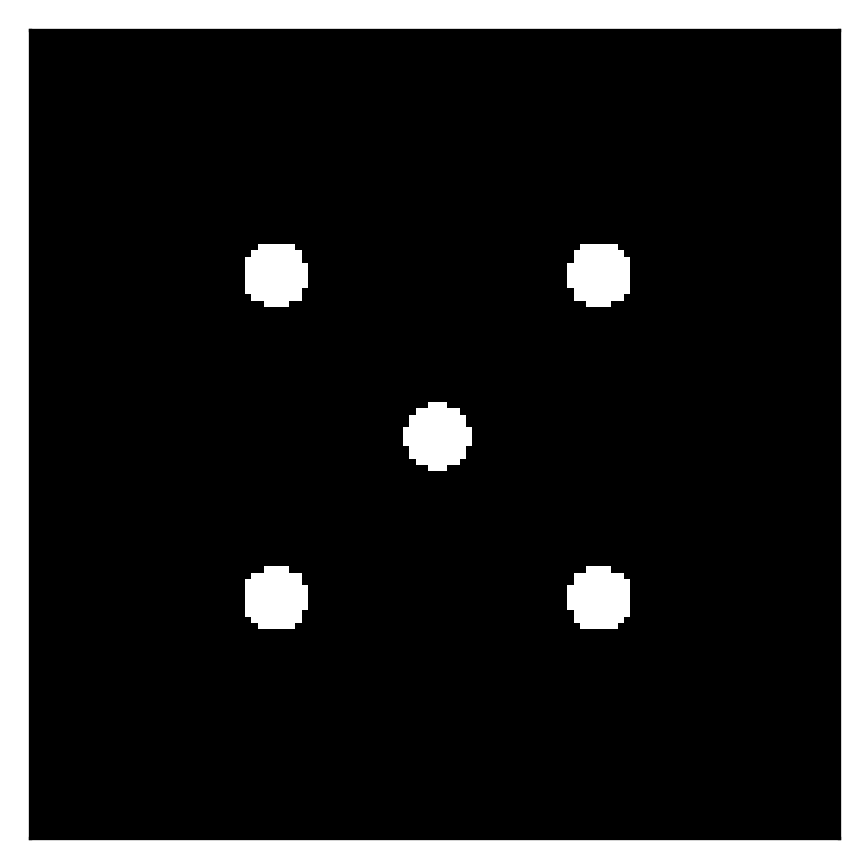

In [74]:
f = Bead_Image(grid, [0.0, 0.01, 0.01, -0.01, -0.01], [0.0, 0.01, -0.01, 0.01, -0.01], [0.002] * 5).image_mask
plot_intensity_clean(x, y, np.flip(f, axis = 0))

In [56]:
rng = np.random.default_rng(30)
true_aberration = generate_johnson_aberration(0.5, alpha)
SNR = 1.0
bias_modes = [[2,2],
              [-2,2],
              [0,4]]

              
bias_strength = 1.0
a_stack = [EmptyAberration()] + [Aberration([m], [bias_strength]) for m in bias_modes] + \
                 [Aberration([m], [-1 * bias_strength]) for m in bias_modes]
img_stack = np.array([get_diversity_image(microscope,f, true_aberration, a, gaussian = True) for a in a_stack])

d_stack = [img + np.random.normal(np.zeros_like(f), np.max(img_stack[0]/100)) for img in img_stack]


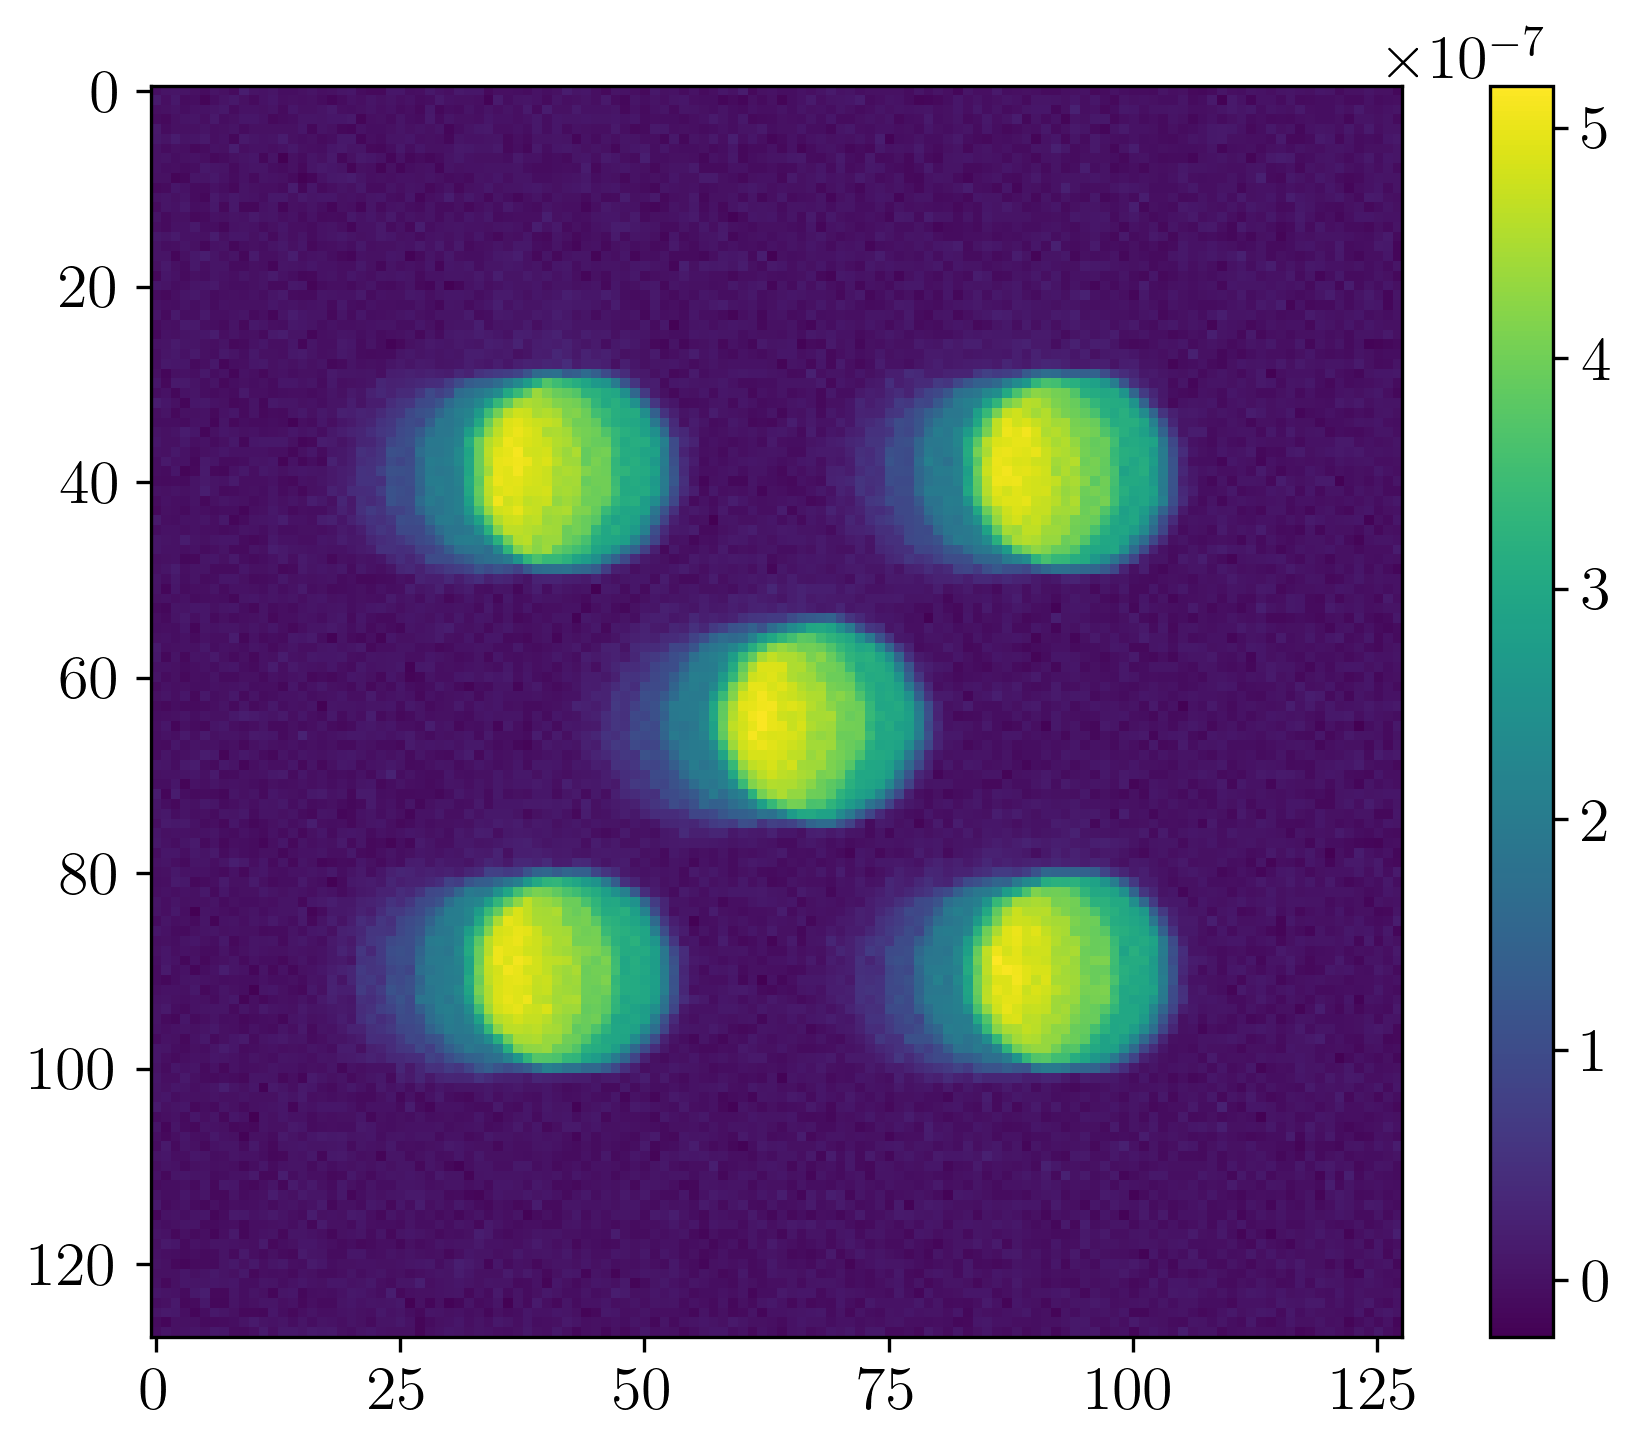

In [59]:
plt.imshow(d_stack[1])
plt.colorbar()

In [64]:
gamma = 1e-24

params = {
                "gamma": gamma,
                "J_tol": 0.001,
                "max_step": 0.05
            }

modes_corrected = get_johnson_modes()


c_guess, F_guess, c_guess_log, F_guess_log, J_log = loop_optimize(n_loops = 2000,
                                microscope = microscope,
                                d_stack = d_stack,
                                a_stack = a_stack,
                                modes_corrected = modes_corrected,
                                params = params,
                                debug = False,
                                log = True,
                                gaussian = True)

 50%|█████     | 1004/2000 [00:35<00:34, 28.54it/s]


In [65]:
max_index = 200
try:
    max_index = np.where(J_log <= 0)[0][0]
except:
    pass
rms_vals = np.zeros(max_index)
for i in range(max_index):
    diff = Aberration(modes_corrected, c_guess_log[i]) - true_aberration
    rms_vals[i] = zernike_RMS(diff, alpha)


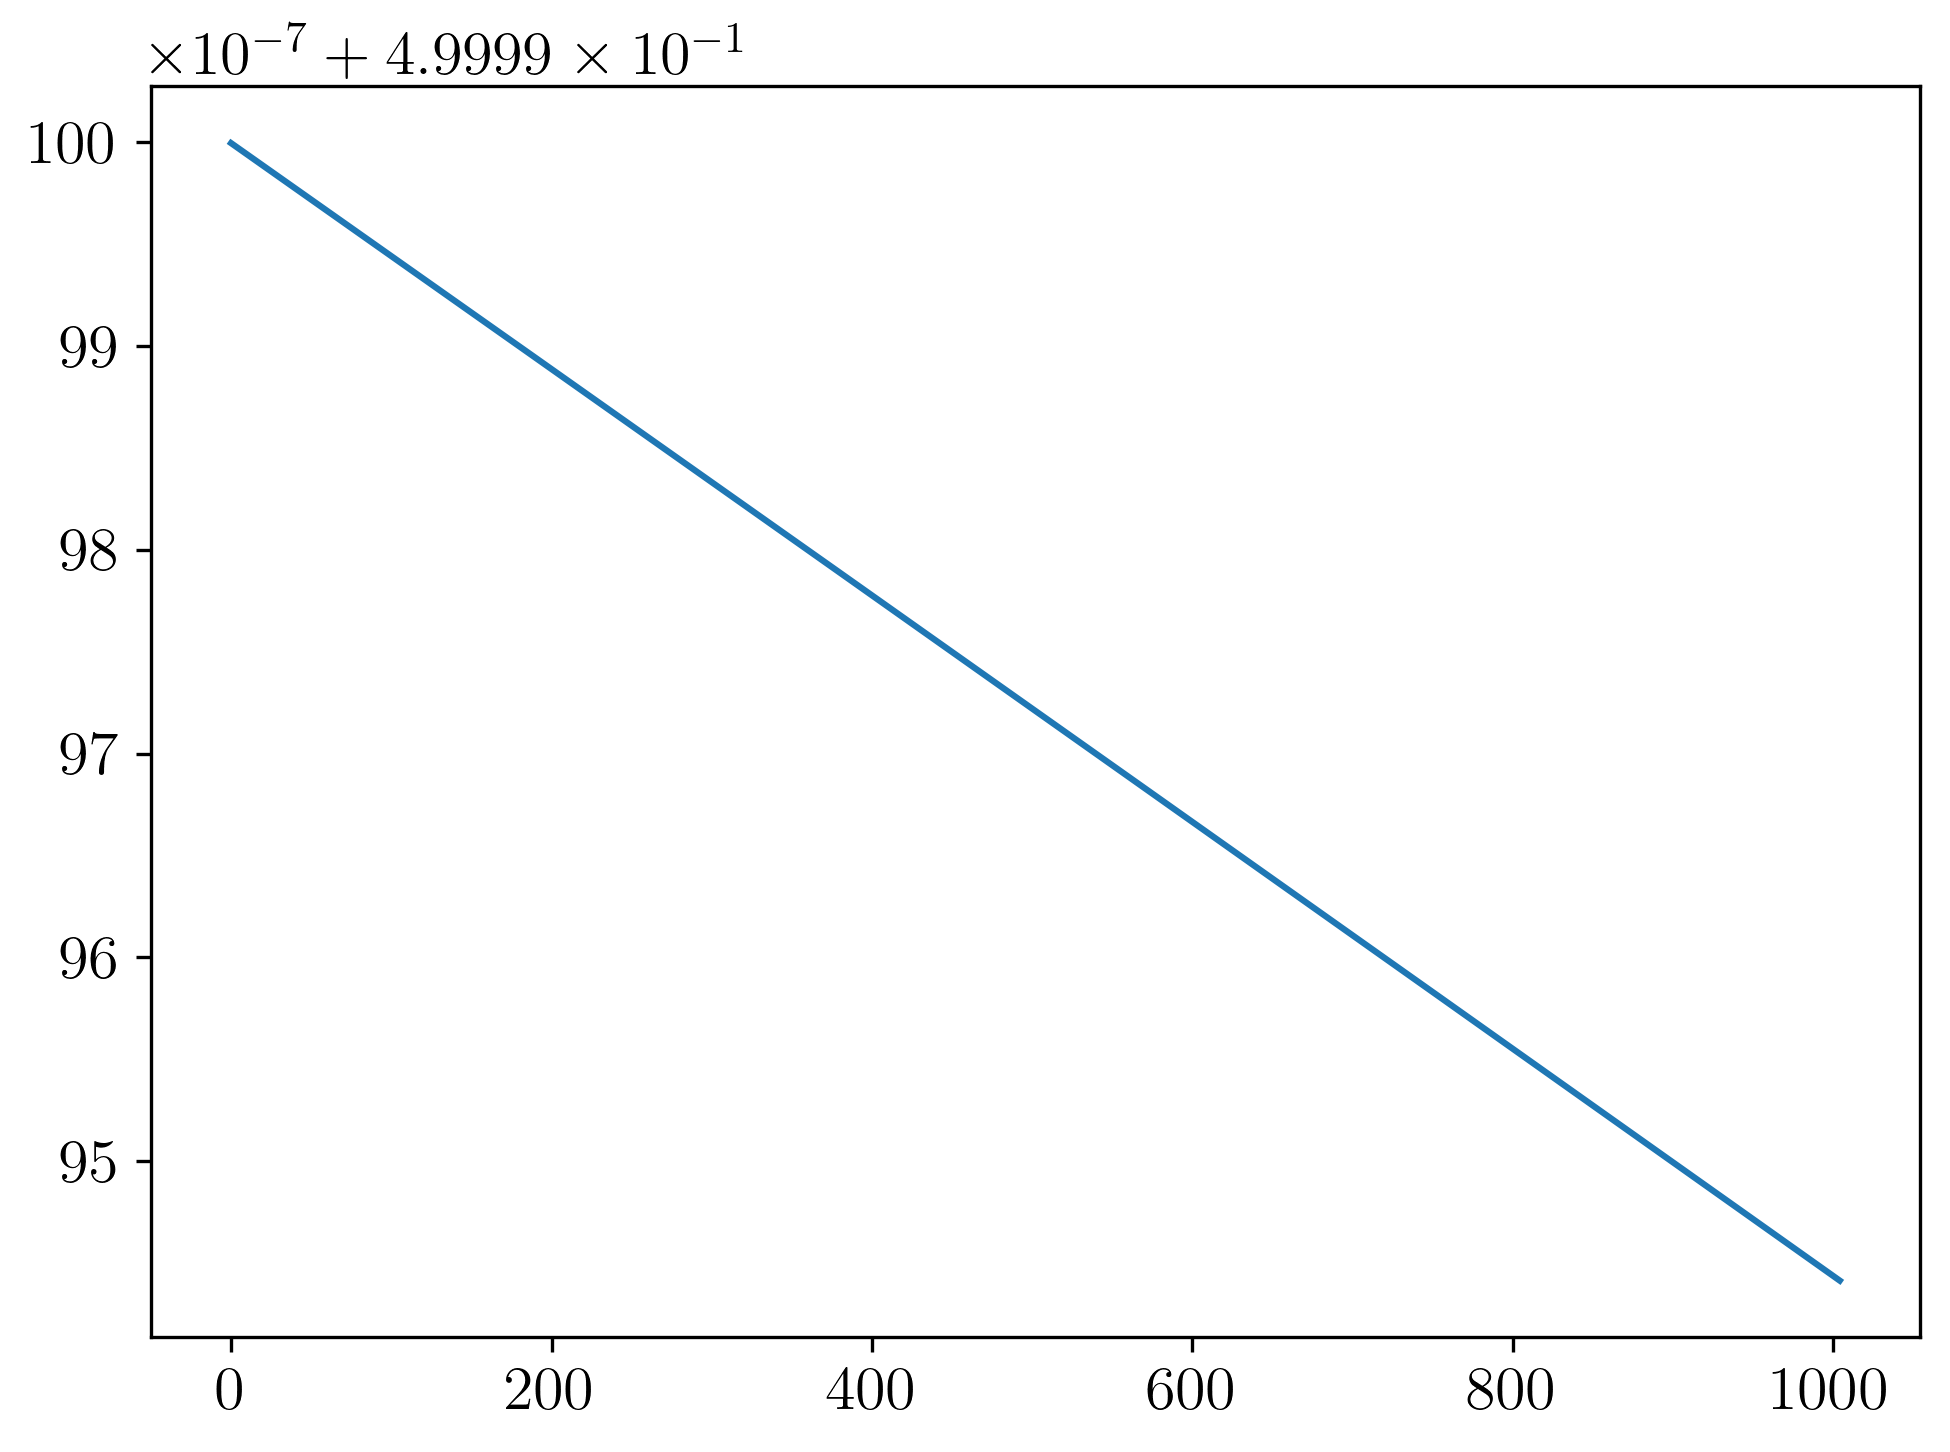

In [66]:
plt.plot(rms_vals)